In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os

downloads = os.path.join(os.path.expanduser("~"), "Downloads")

filename = os.path.join(downloads, "Fluc_erg_CS_Kac_OP.npz")

data = np.load(filename)

# extract arrays
N_arr = data["N"]
E_ergo = data["Eerg"]
E_var = data["variance"]
E_ratio = data["ratio"]
E_B = data["Eb"]

# derived quantities
F_ratio = np.sqrt(E_var) / E_ergo
FE_ratio = np.sqrt(E_var) / E_B

In [ ]:
N = data["N"]
tau = data["tau"]
Eb = data["Eb"]
Eerg = data["Eerg"]
ratio = data["ratio"]
variance = data["variance"]

for i in range(len(N)):
    print(
        f"N={N[i]}, "
        f"τ={tau[i]:.4f}, "
        f"Eb={Eb[i]:.6f}, "
        f"Ergotropy={Eerg[i]:.6f}, "
        f"Ratio={ratio[i]:.6f}, "
        f"Variance={variance[i]:.10e},"
        f"Fluctuation w.r.t erg={F_ratio[i]:.10e},"
        f"Fluctuation w.r.t EB={FE_ratio[i]:.10e}"
    )

N=2, τ=1.1800, Eb=1.709793, Ergotropy=1.440640, Ratio=0.842582, Variance=8.6900148192e-01,Fluctuation w.r.t erg=6.4707516002e-01,Fluctuation w.r.t EB=5.4521379585e-01
N=6, τ=0.9821, Eb=4.849158, Ergotropy=4.296836, Ratio=0.886099, Variance=2.2342495159e+00,Fluctuation w.r.t erg=3.4787005645e-01,Fluctuation w.r.t EB=3.0824747651e-01
N=10, τ=0.8842, Eb=8.172562, Ergotropy=7.622709, Ratio=0.932720, Variance=5.4895961315e+00,Fluctuation w.r.t erg=3.0736956805e-01,Fluctuation w.r.t EB=2.8668962241e-01
N=14, τ=0.8164, Eb=11.562063, Ergotropy=10.984431, Ratio=0.950041, Variance=9.5743665022e+00,Fluctuation w.r.t erg=2.8169391918e-01,Fluctuation w.r.t EB=2.6762068439e-01
N=18, τ=0.7650, Eb=14.987682, Ergotropy=14.375202, Ratio=0.959134, Variance=1.4435739995e+01,Fluctuation w.r.t erg=2.6430511611e-01,Fluctuation w.r.t EB=2.5350414737e-01
N=22, τ=0.7240, Eb=18.436889, Ergotropy=17.789038, Ratio=0.964861, Variance=2.0058092030e+01,Fluctuation w.r.t erg=2.5176325712e-01,Fluctuation w.r.t EB=2.429

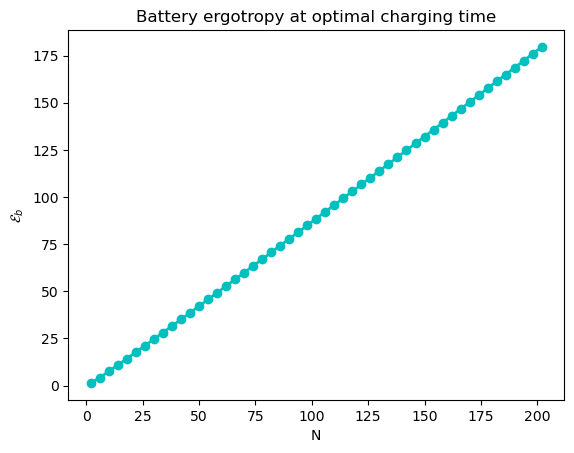

In [ ]:
###############################################################
# Plot of battery ergotropy at optimal charging for different N
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("OP1")
plt.show()

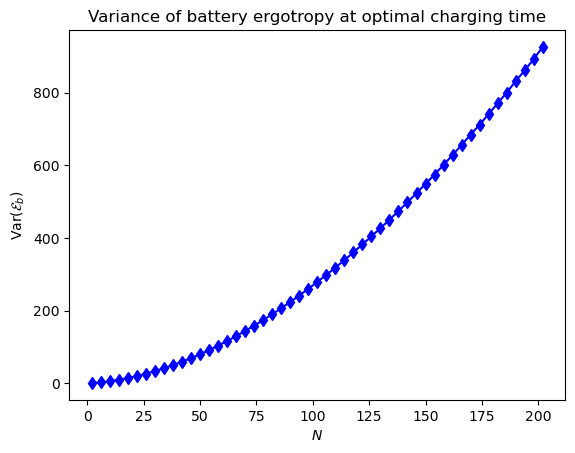

In [ ]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("OP2")
plt.show()

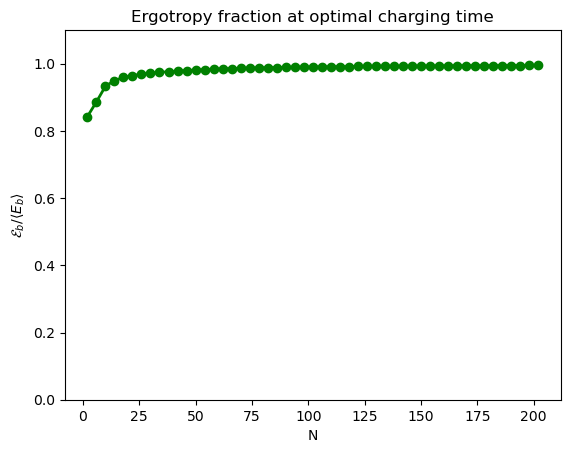

In [ ]:
#############################################################
# Plot ergotropy fraction as a function of g for different N
############################################################

plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
# plt.savefig("OP3")
plt.show()

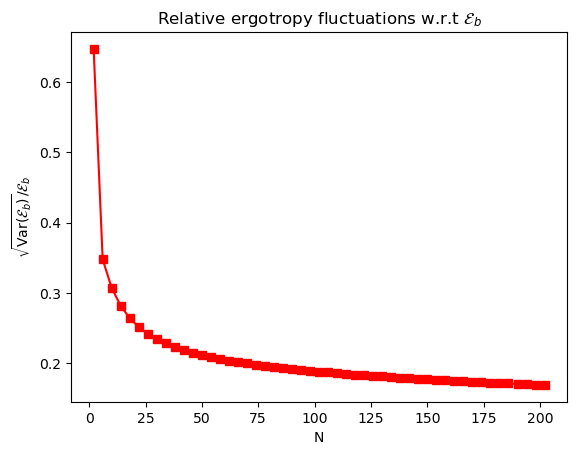

In [ ]:
######################################################
# Plot fluctuations as a function of g for different N
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
# plt.savefig("OP4")
plt.show()

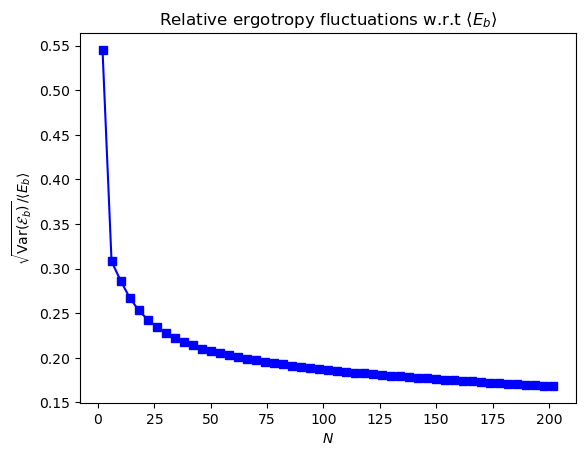

In [ ]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
# plt.savefig("OP5")
plt.show()

### Scaling of $1 - \mathcal{E}_b / E_{b}$

Best fit parameter: A = 1.019748


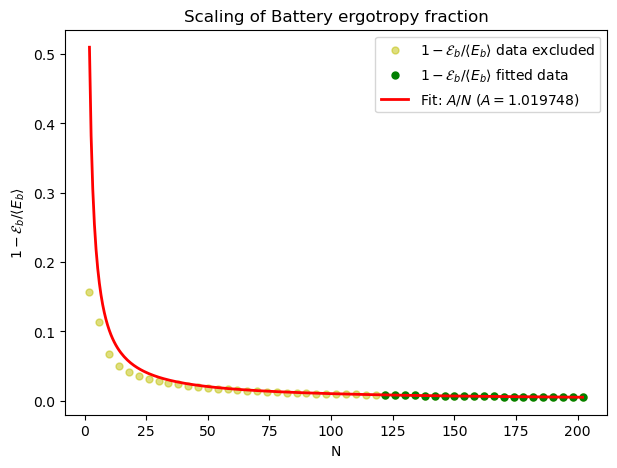

In [ ]:
###############################
# Scaling using a linear plot
##############################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function
def asymptotic_fit(N, A):
    return A / N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data = N_arr[30:51]
y_data = 1 - np.array(E_ratio[30:51])

# Fit only restricted region
popt, pcov = curve_fit(asymptotic_fit, N_data, y_data)

A_opt = popt[0]

print(f"Best fit parameter: A = {A_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_fit = asymptotic_fit(N_smooth, A_opt)

plt.figure(figsize=(7, 5))

# Plot the FULL dataset with faded colours
plt.plot(N_arr, y_full, 'o', color='y', markersize=5, alpha=0.5, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$ data excluded")

# Plot restricted actual data
plt.plot(N_data, y_data, 'o', color='g', markersize=5, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$ fitted data")

# Plot fit over FULL range
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A/N$ ($A={A_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Scaling of Battery ergotropy fraction")
plt.legend()
plt.show()

In [1]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit(log_N, logA, alpha):
    return logA - alpha *log_N

y_full = 1 - np.array(E_ratio)

# Restrict fitting data
N_data = N_arr[12:51]
y_data = y_full[12:51]

# Keep only positive values for the logarithm
mask = (N_data > 0) & (y_data > 0)

N_fit = N_data[mask]
y_fit_data = y_data[mask]

# Logarithmic variables
log_N = np.log(N_fit)
log_y = np.log(y_fit_data)

# Fit in log-space
popt, pcov = curve_fit(log_fit, log_N, log_y)

logA_opt, alpha_opt = popt

A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}, alpha = {alpha_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / (N_smooth**alpha_opt)

plt.figure(figsize=(7, 5))

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$ fitted data")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=rf'Fit: $\log y = \log A - \alpha\log N$')

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title("Logarithmic Scaling of Battery ergotropy fraction")
plt.legend()
plt.show()

NameError: name 'E_ratio' is not defined

### Scaling of $\sqrt var(\mathcal{E}_b) / \mathcal{E}_b$

Best fit parameter: A = 19.396380


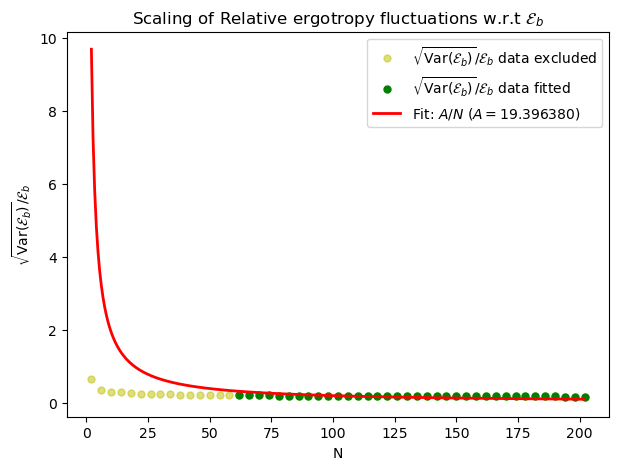

In [ ]:
###############################
# Scaling using a linear plot
##############################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function
def asymptotic_fit(N, A):
    return A / N

y_full = np.array(F_ratio)

# Restrict fitting data
N_data = N_arr[15:51]
y_data = np.array(F_ratio[15:51])

# Fit only restricted region
popt, pcov = curve_fit(asymptotic_fit, N_data, y_data)

A_opt = popt[0]

print(f"Best fit parameter: A = {A_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_fit = asymptotic_fit(N_smooth, A_opt)

plt.figure(figsize=(7, 5))

# Plot the FULL dataset with faded colours
plt.plot(N_arr, y_full, 'o', color='y', markersize=5, alpha=0.5, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data excluded")

# Plot restricted actual data
plt.plot(N_data, y_data, 'o', color='g', markersize=5, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data fitted")

# Plot fit over FULL range
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A/N$ ($A={A_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.show()

Best fit parameter: A = 24.695490


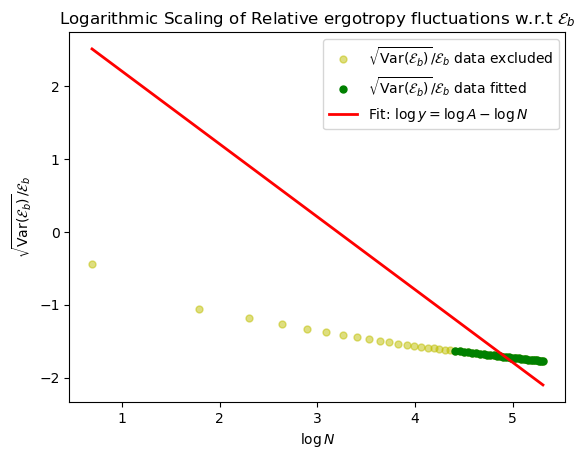

In [ ]:
###################################
# Scaling using a logarithmic plot
###################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function in log-space
def log_fit(log_N, logA):
    return logA - log_N

y_full = np.array(F_ratio)

# Restrict fitting data
N_data = N_arr[20:51]
y_data = y_full[20:51]

# Keep only positive values for the logarithm
mask = (N_data > 0) & (y_data > 0)

N_fit = N_data[mask]
y_fit_data = y_data[mask]

# Logarithmic variables
log_N = np.log(N_fit)
log_y = np.log(y_fit_data)

# Fit in log-space
popt, pcov = curve_fit(log_fit, log_N, log_y)

logA_opt = popt[0]
A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}")

# Smooth curve over FULL N range
N_smooth = np.linspace(min(N_arr), max(N_arr), 300)

y_smooth = A_opt / N_smooth

plt.figure()

# Plot FULL dataset with faded colours
plt.plot(np.log(N_arr[y_full > 0]), np.log(y_full[y_full > 0]), 'o', color='y', markersize=5, alpha=0.5,label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data excluded")

# Plot restricted fitted data
plt.plot(log_N, log_y, 'o', color='g', markersize=5, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$ data fitted")

# Plot fitted line over FULL range
plt.plot(np.log(N_smooth), np.log(y_smooth), '-', color='r', linewidth=2, label=rf'Fit: $\log y = \log A - \log N$')

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Logarithmic Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.show()